In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import backtest.run

mid, sigma, events = backtest.run.load_artifacts()

In [12]:
train_results = backtest.run.run(mid, sigma, events)

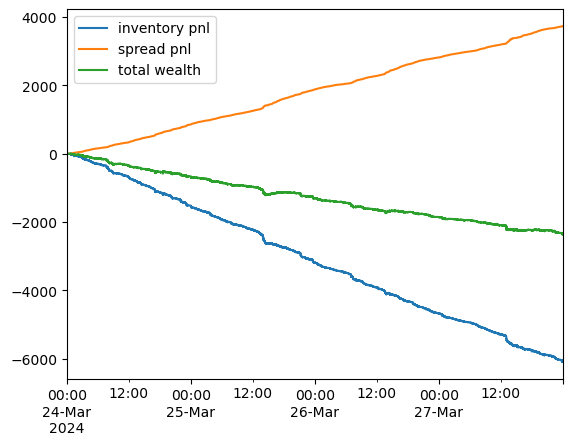

In [13]:
import matplotlib.pyplot as plt

inv_pnl = (train_results['q'].shift() * train_results['mid'].diff()).cumsum() # compute inventory riding market movement
spread_pnl = (train_results['wealth'] - train_results['wealth'].dropna().iloc[0]) - inv_pnl # cash flow

inv_pnl.plot(label = 'inventory pnl')
spread_pnl.plot(label = 'spread pnl')
train_results['wealth'].plot(label = 'total wealth')
plt.legend()
plt.show()

In [14]:
# average half-spread

print((train_results['ask_quote'] - train_results['bid_quote']).mean() / 2)

8.8827301099638


In [18]:
import backtest.symmetric_strategy

symmetric_results = backtest.run.run(mid, sigma, events, 
                                     strategy_cls = backtest.symmetric_strategy.SymmetricStrategy,
                                     strategy_kwargs = {'half_spread': 8.88})

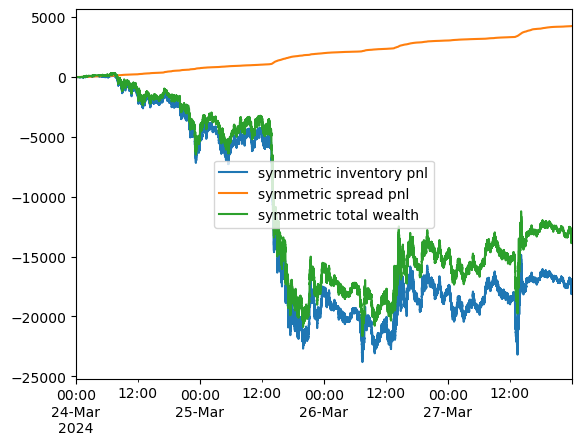

In [22]:
sym_inv_pnl = (symmetric_results['q'].shift() * symmetric_results['mid'].diff()).cumsum() # compute inventory riding market movement
sym_spread_pnl = (symmetric_results['wealth'] - symmetric_results['wealth'].dropna().iloc[0]) - inv_pnl # cash flow

sym_inv_pnl.plot(label = 'symmetric inventory pnl')
sym_spread_pnl.plot(label = 'symmetric spread pnl')
symmetric_results['wealth'].plot(label = 'symmetric total wealth')
plt.legend()
plt.show()

In [20]:
train_results.to_parquet('binance/as_results')
symmetric_results.to_parquet('binance/symmetric_results')